### Dependencias

In [ ]:
%pip install pillow numpy matplotlib opencv-python scikit-image


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import cv2
from skimage import exposure, img_as_float, img_as_ubyte


### TAREFA 1 – OPERAÇÕES GEOMÉTRICAS

#### a) Seleção da região [y=85:200, x=325:475] da imagem prc_papa.jpg


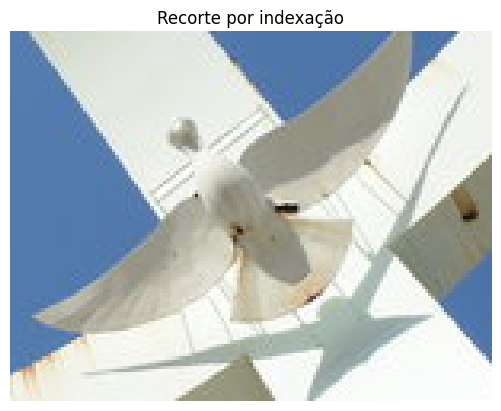

In [3]:
# i. Usando indexação:
img = np.array(Image.open("prc_papa.jpg"))
crop_manual = img[85:201, 325:476]
plt.imshow(crop_manual)
plt.title("Recorte por indexação")
plt.axis('off')
plt.show()


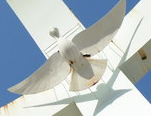

In [6]:
# ii. Usando Image.crop() (Pillow):
img_pil = Image.open("prc_papa.jpg")
crop_pillow = img_pil.crop((325, 85, 476, 201))  # (left, top, right, bottom)
display(crop_pillow)

#### b) Equalização do histograma

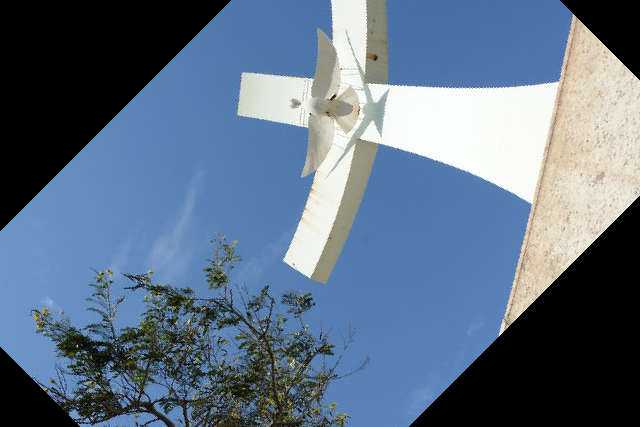

In [9]:
rotated = img_pil.rotate(45)  # rotação de 45 graus
display(rotated)


### TAREFA 2 – TRANSFORMAÇÕES DE INTENSIDADE

#### a) Negativo da imagem prc_papa.jpg


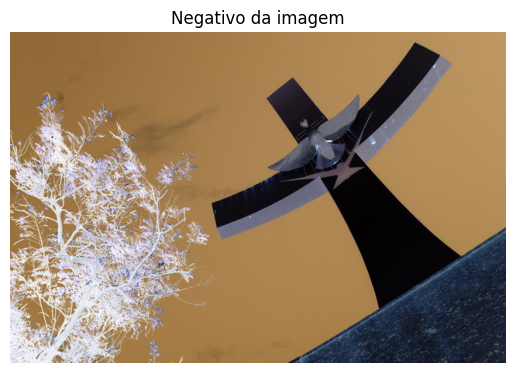

In [10]:
img = np.array(Image.open("prc_papa.jpg"))
negative = 255 - img
plt.imshow(negative)
plt.title("Negativo da imagem")
plt.axis('off')
plt.show()


#### b) Clarear imagem com transformação logarítmica


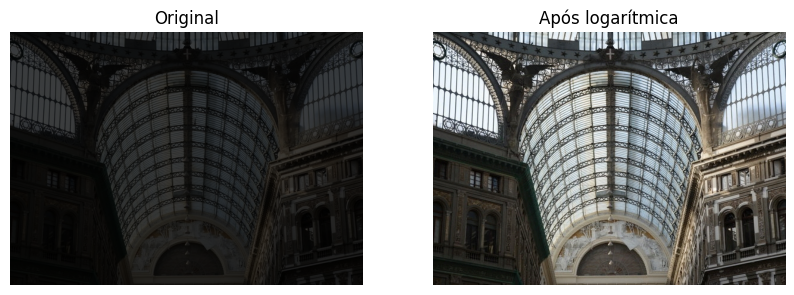

In [14]:
img_napoli = np.array(Image.open("napoli_mall_low_intensity.png"))
img_napoli_float = img_as_float(img_napoli)

log_img = np.log1p(img_napoli_float)
log_img = (log_img / log_img.max()) * 255
log_img = log_img.astype(np.uint8)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_napoli)
plt.title("Original")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(log_img)
plt.title("Após logarítmica")
plt.axis('off')
plt.show()


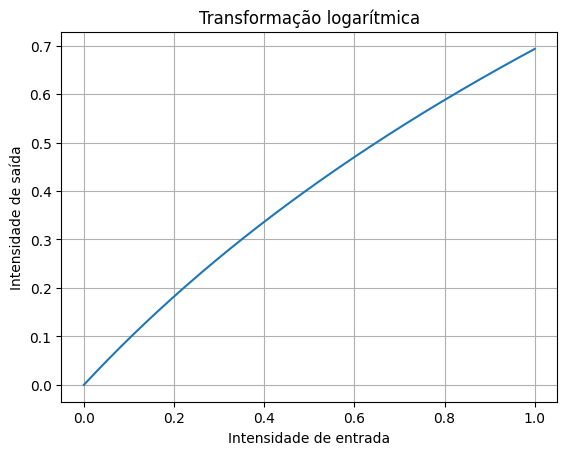

In [15]:
# Gráfico da transformação
x = np.linspace(0, 1, 256)
y = np.log1p(x)
plt.plot(x, y)
plt.title("Transformação logarítmica")
plt.xlabel("Intensidade de entrada")
plt.ylabel("Intensidade de saída")
plt.grid()
plt.show()

#### c) Conversão para float16 + normalização para [0, 1]

In [21]:
img = np.array(Image.open("prc_papa.jpg"))
img_float = img.astype(np.float16)
img_norm = img_float / 255.0

plt.imshow(img_norm)
plt.title("Imagem normalizada (float16)")
plt.axis('off')
plt.show()


ValueError: arrays must be of dtype byte, short, float32 or float64

<Figure size 640x480 with 1 Axes>

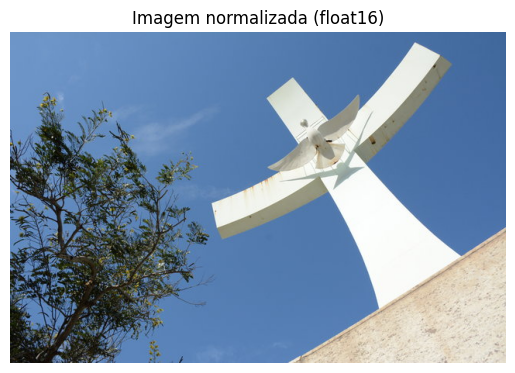

In [20]:
img = np.array(Image.open("prc_papa.jpg"))
img_float = img.astype(np.float32)
img_norm = img_float / 255.0

plt.imshow(img_norm)
plt.title("Imagem normalizada (float16)")
plt.axis('off')
plt.show()


In [23]:
img_uint_norm = img / 255  # permanece como int → resultado incorreto
print("Tipo sem conversão:", img_uint_norm.dtype)


Tipo sem conversão: float64


### TAREFA 3 – HISTOGRAMAS

#### a) Histograma da imagem pompeii_low_contrast.png

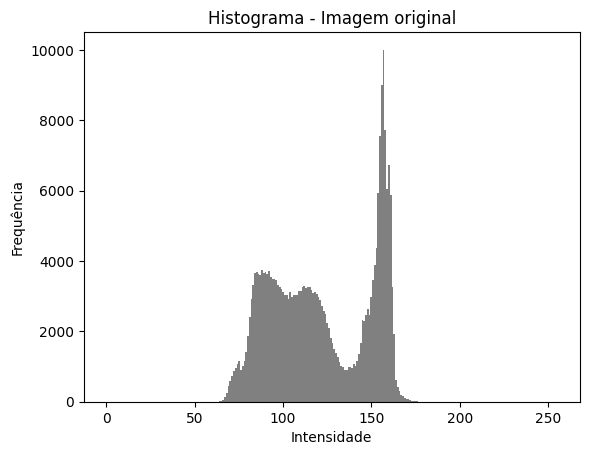

In [24]:
img_pompeii = np.array(Image.open("pompeii_low_contrast.png").convert('L'))
plt.hist(img_pompeii.ravel(), bins=256, range=(0,255), color='gray')
plt.title("Histograma - Imagem original")
plt.xlabel("Intensidade")
plt.ylabel("Frequência")
plt.show()


#### b) Equalização do histograma

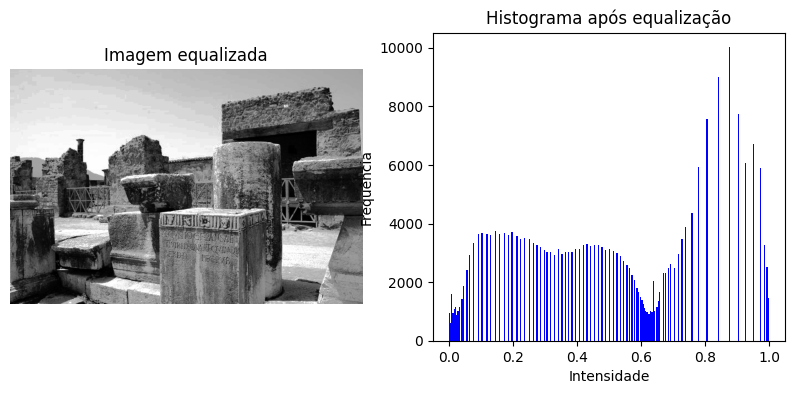

In [25]:
img_eq = exposure.equalize_hist(img_pompeii)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_eq, cmap='gray')
plt.title("Imagem equalizada")
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(img_eq.ravel(), bins=256, range=(0,1), color='blue')
plt.title("Histograma após equalização")
plt.xlabel("Intensidade")
plt.ylabel("Frequência")
plt.show()


#### c) Diferença entre histogramas?
Sim, o histograma da imagem original é concentrado (baixo contraste). Após a equalização, a distribuição de tons é mais uniforme, aumentando o contraste da imagem.

